# Lab 1 - Pipeline di fine-tuning

Questo notebook copre l'**Esercizio 1.3: A Fine-tuning Baseline** e prepara l'**Esercizio 2: Consolidamento della pipeline**.

L'obiettivo e' passare dalla baseline stabile basata su feature ResNet-18 + SVM a una baseline di fine-tuning semplice, riproducibile e spiegabile. In questa fase alleniamo solo il classificatore finale della ResNet-18, mantenendo congelato il backbone pre-addestrato su ImageNet.


> **Nota di esecuzione**
>
> Gli output visibili sono stati prodotti durante le esecuzioni finali o di validazione del laboratorio. Nella versione di consegna i training costosi sono disattivati di default quando sono controllati da flag; checkpoint e artefatti salvati vengono usati per consultazione rapida.


## Richieste dell'esercizio

L'Esercizio 1.3 richiede di:

- caricare una ResNet-18 pre-addestrata;
- sostituire il classificatore finale con una nuova testa per le 43 classi GTSRB;
- allenare il modello per alcune epoche;
- monitorare non solo il training loss, ma anche la validation loss su uno split indipendente;
- valutare se il solo fine-tuning della testa finale migliora la baseline precedente.

Per evitare notebook ripetitivi, gli esperimenti vecchi con diverse loss e optimizer vengono riassunti in una tabella. La run eseguita qui e' solo quella piu' significativa: `Adam + CrossEntropy`, cioe' la migliore tra le prove head-only precedenti.


In [1]:
from pathlib import Path

import pandas as pd
import torch

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

from dla_lab1.config import experiment_config, load_config
from dla_lab1.data import build_dataloaders, missing_classes_in_split
from dla_lab1.evaluate import classification_metrics, history_to_frame, predict
from dla_lab1.experiments import batch_size_for, run_finetuning
from dla_lab1.models import build_classifier, count_parameters
from dla_lab1.seed import seed_everything
from dla_lab1.train import configure_torch_for_hardware, resolve_device
from dla_lab1.visualize import plot_training_history

config = load_config(ROOT / "config" / "config.yaml")

# Non rilanciamo automaticamente il training lungo.
RUN_TRAINING = False
# Se RUN_TRAINING=True, la run viene salvata anche su Weights & Biases.
ENABLE_WANDB = False
config["wandb"]["enabled"] = ENABLE_WANDB
config["wandb"]["group"] = "exercise_1_3_finetuning_baseline"
# Valore pratico per notebook interattivo su Windows; riduci a 0 se il kernel si blocca.
config["dataset"]["num_workers"] = 4
seed_everything(int(config["project"]["seed"]))

device = resolve_device(config["project"].get("device", "auto"))
configure_torch_for_hardware(device, bool(config["hardware"].get("allow_tf32", True)))

print(f"Radice del progetto: {ROOT.name}")
print(f"Device: {device}")
print(f"PyTorch: {torch.__version__}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")


Project root: DLA_1
Device: cuda
PyTorch: 2.10.0
GPU: NVIDIA GeForce RTX 2050


## Configurazione della run

Per mantenere un buon rapporto tra costo e prestazioni sul PC disponibile, questa run usa:

- **ResNet-18**, non un modello piu' pesante;
- **backbone congelato**, quindi si addestra solo la `fc` finale;
- **batch size 64**, uguale alle prove vecchie e adatto a una GPU da 4 GB;
- **10 epoche**, sufficienti per una baseline senza rendere il notebook troppo lento;
- **learning rate 0.001**, coerente con lo screening preliminare;
- **AMP attivo** quando si usa CUDA, per velocizzare il training e ridurre memoria.


In [2]:
EXPERIMENT_NAME = "ex1_3_head_only_adam_ce"
exp_cfg = experiment_config(config, EXPERIMENT_NAME)
training_cfg = exp_cfg["training"]
batch_size = batch_size_for(config, exp_cfg["experiment"]["batch_size_key"])

run_setup = pd.DataFrame([
    ["experiment", EXPERIMENT_NAME],
    ["model", exp_cfg["model"]["name"]],
    ["weights", exp_cfg["model"].get("weights")],
    ["freeze_backbone", exp_cfg["model"].get("freeze_backbone")],
    ["unfreeze_layer4", exp_cfg["model"].get("unfreeze_layer4")],
    ["loss", training_cfg["loss"]],
    ["optimizer", training_cfg["optimizer"]],
    ["learning_rate", training_cfg["learning_rate"]],
    ["batch_size", batch_size],
    ["epochs", training_cfg["epochs"]],
    ["scheduler", training_cfg["scheduler"]],
    ["use_amp", training_cfg["use_amp"] and device.type == "cuda"],
], columns=["parameter", "value"])

run_setup


,parameter,value
0,experiment,ex1_3_head_only_adam_ce
1,model,resnet18
2,weights,DEFAULT
3,freeze_backbone,True
4,unfreeze_layer4,False
5,loss,CrossEntropy
6,optimizer,Adam
7,learning_rate,0.001
8,batch_size,128
9,epochs,10


## Split di validazione

Il test set ufficiale non viene usato per scegliere gli iperparametri. Per monitorare overfitting e stabilita' della run, dividiamo il training set in train e validation.

Lo split e' costruito per classe e per piccoli gruppi consecutivi di immagini, per ridurre il rischio che immagini quasi identiche finiscano sia in train sia in validation. Qui controlliamo esplicitamente che la validation contenga almeno un elemento per ognuna delle 43 classi.


In [3]:
loaders = build_dataloaders(
    data_root=ROOT / config["paths"]["data_root"],
    image_size=int(config["dataset"]["image_size"]),
    batch_size=batch_size,
    val_split=float(config["dataset"]["val_split"]),
    track_size=int(config["dataset"]["track_size"]),
    seed=int(config["project"]["seed"]),
    num_workers=int(config["dataset"]["num_workers"]),
    pin_memory=bool(config["dataset"]["pin_memory"]),
    augmentation="none",
)

split_summary = loaders["split_summary"]
missing_val_classes = missing_classes_in_split(split_summary, "val_count")
missing_train_classes = missing_classes_in_split(split_summary, "train_count")

split_check = pd.DataFrame([
    ["train samples", int(split_summary["train_count"].sum())],
    ["validation samples", int(split_summary["val_count"].sum())],
    ["classes in train", int((split_summary["train_count"] > 0).sum())],
    ["classes in validation", int((split_summary["val_count"] > 0).sum())],
    ["missing train classes", missing_train_classes],
    ["missing validation classes", missing_val_classes],
    ["min validation samples per class", int(split_summary["val_count"].min())],
    ["max validation samples per class", int(split_summary["val_count"].max())],
], columns=["check", "value"])

assert not missing_train_classes, f"Classi mancanti nel train split: {missing_train_classes}"
assert not missing_val_classes, f"Classi mancanti nella validation: {missing_val_classes}"

split_check


,check,value
0,train samples,20820
1,validation samples,5820
2,classes in train,43
3,classes in validation,43
4,missing train classes,[]
5,missing validation classes,[]
6,min validation samples per class,30
7,max validation samples per class,300


In [4]:
split_summary.head(10)


,class_id,train_count,val_count,total_count,val_ratio
0,0,120,30,150,0.200000
1,1,1200,300,1500,0.200000
2,2,1200,300,1500,0.200000
3,3,750,210,960,0.218750
4,4,1050,270,1320,0.204545
5,5,990,270,1260,0.214286
6,6,240,60,300,0.200000
7,7,750,210,960,0.218750
8,8,750,210,960,0.218750
9,9,780,210,990,0.212121


## Screening preliminare delle prove head-only

Nel vecchio notebook erano state provate diverse configurazioni head-only, sempre con backbone congelato e solo classificatore finale addestrabile.

Qui resta soltanto l'elenco delle prove di screening; le metriche finali derivano dalla pipeline tecnica e dagli artifact versionati.


Prove svolte:

- `Adam_CrossEntropy`
- `AdamW_CrossEntropy`
- `SGD_CrossEntropy`
- `Adam_WeightedCrossEntropy`
- `AdamW_WeightedCrossEntropy`
- `SGD_WeightedCrossEntropy`
- `Adam_FocalLoss`
- `AdamW_FocalLoss`
- `SGD_FocalLoss`


Queste prove servono solo a documentare lo screening fatto durante la fase esplorativa.

Nel notebook corrente non riportiamo accuracy, loss o best epoch copiati dalle run vecchie: eventuali risultati devono essere rigenerati con la pipeline corrente oppure consultati nell'archivio degli esperimenti di prova.


## Controllo del modello

Prima di allenare, verifichiamo che la ResNet-18 abbia davvero il backbone congelato e che siano addestrabili solo i parametri della nuova testa finale.


In [5]:
model = build_classifier(
    model_name=exp_cfg["model"]["name"],
    num_classes=int(config["project"]["num_classes"]),
    weights=exp_cfg["model"].get("weights", "DEFAULT"),
    freeze_backbone=bool(exp_cfg["model"].get("freeze_backbone", True)),
    unfreeze_layer4=bool(exp_cfg["model"].get("unfreeze_layer4", False)),
)

pd.DataFrame([count_parameters(model)])


,total,trainable
0,11198571,22059


## Training della baseline head-only

Questa e' la run principale dell'Esercizio 1.3. Il training loop non e' scritto manualmente nel notebook: viene richiamato da `src/dla_lab1`, in modo che la pipeline sia riutilizzabile e configurabile.

Non viene mantenuta nessuna history precompilata: se `RUN_TRAINING = False`, la cella non mostra risultati storici.


### Cross-entropy della baseline

Per un batch di $N$ esempi, la testa a 43 classi è ottimizzata con

$$
\mathcal{L}_{\mathrm{CE}}
=
-\frac{1}{N}\sum_{i=1}^{N}\log p_{\theta}(y_i\mid x_i).
$$

dove:

- $N$ è il numero di esempi nel batch;
- $x_i$ è l'immagine dell'esempio $i$;
- $y_i$ è la classe corretta;
- $p_{\theta}(y_i\mid x_i)$ è la probabilità assegnata dal modello alla classe corretta;
- $\theta$ rappresenta i parametri del modello.

La loss cresce quando il modello assegna poca probabilità alla classe corretta. `train_model` chiama `build_loss` in `src/dla_lab1/losses.py`, che per questa configurazione restituisce `nn.CrossEntropyLoss`; soltanto la testa `fc` ha `requires_grad=True`.


In [6]:
result = None
history = None

if RUN_TRAINING:
    config["wandb"]["enabled"] = ENABLE_WANDB
    config["wandb"]["group"] = "exercise_1_3_finetuning_baseline"
    result = run_finetuning(config, EXPERIMENT_NAME, root=ROOT)
    history = history_to_frame(result["history"])
    display(history)


  0%|          | 0/163 [00:21<?, ?it/s]

  0%|          | 0/46 [00:25<?, ?it/s]

Epoch 01 | lr=1.00e-03 | train_loss=1.9356 train_acc=0.4822 | val_loss=2.1151 val_acc=0.4050


  0%|          | 0/163 [00:00<?, ?it/s]

  0%|          | 0/46 [00:00<?, ?it/s]

...

  0%|          | 0/163 [00:00<?, ?it/s]

  0%|          | 0/46 [00:00<?, ?it/s]

Epoch 10 | lr=1.00e-05 | train_loss=0.6149 train_acc=0.8273 | val_loss=2.0463 val_acc=0.4655


epoch,▁▂▃▃▄▅▆▆▇█
learning_rate,████▂▂▂▂▁▁
train/accuracy,▁▅▇▇██████
train/loss,█▃▂▂▁▁▁▁▁▁
validation/accuracy,▁▆▇▆▇█████
validation/loss,█▁▁▆▃▃▄▄▃▃
best_val_acc,0.46667
epoch,10
learning_rate,1e-05
train/accuracy,0.82733
train/loss,0.61485


,epoch,train_loss,train_acc,val_loss,val_acc,learning_rate
0,1,1.935596,0.482229,2.115052,0.404983,0.00100
1,2,1.054165,0.703554,2.018695,0.448454,0.00100
2,3,0.838443,0.761095,2.023475,0.456014,0.00100
3,4,0.735079,0.788136,2.091318,0.452405,0.00100
4,5,0.650791,0.817195,2.048851,0.460653,0.00010
5,6,0.638969,0.818732,2.043865,0.466667,0.00010
6,7,0.630859,0.821806,2.063261,0.462543,0.00010
7,8,0.622522,0.823919,2.054412,0.464777,0.00010
8,9,0.610659,0.834342,2.041774,0.465464,0.00001
9,10,0.614854,0.827329,2.046325,0.465464,0.00001


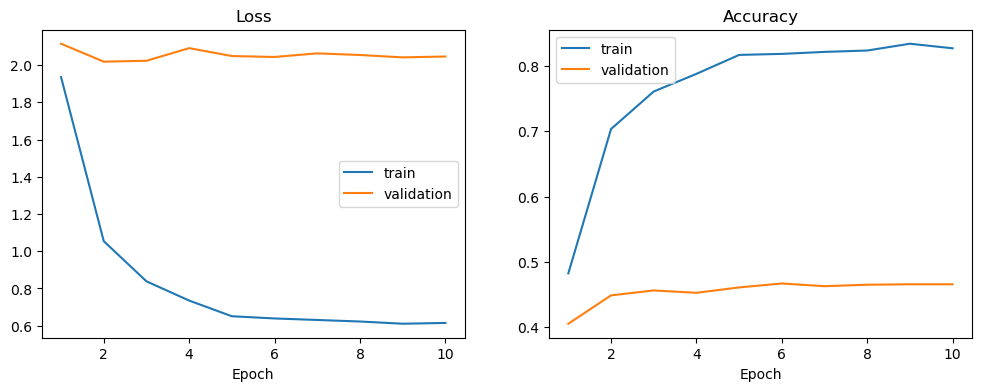

In [7]:
if history is not None:
    plot_training_history(history)


## Valutazione su validation

Valutiamo il miglior checkpoint sulla validation. Questa valutazione serve a capire se la baseline di fine-tuning head-only e' competitiva rispetto alla baseline precedente feature extractor + SVM.


In [8]:
val_metrics = None

if result is not None and history is not None:
    best_row = history.loc[history["val_acc"].idxmax()]
    y_true_val, y_pred_val = predict(result["model"], result["loaders"]["val"], result["device"])
    val_metrics = classification_metrics(y_true_val.numpy(), y_pred_val.numpy())

    validation_summary = pd.DataFrame([
        ["best_epoch", int(best_row["epoch"])],
        ["best_val_accuracy_from_training", float(best_row["val_acc"])],
        ["validation_accuracy_recomputed", float(val_metrics["accuracy"])],
    ], columns=["metric", "value"])

    display(validation_summary)


,metric,value
0,best_epoch,6.000000
1,best_val_accuracy_from_training,0.466667
2,validation_accuracy_recomputed,0.466667


In [9]:
if val_metrics is not None:
    print(val_metrics["classification_report"])
else:
    print("Classification report disponibile solo se RUN_TRAINING = False, perche' richiede il modello caricato in memoria.")


              precision    recall  f1-score   support

           0       0.56      0.30      0.39        30
           1       0.35      0.33      0.34       300
           2       0.25      0.25      0.25       300
           3       0.46      0.45      0.46       210
           4       0.44      0.45      0.44       270
           5       0.36      0.44      0.40       270
           6       0.53      0.83      0.65        60
           7       0.43      0.46      0.44       210
           8       0.34      0.31      0.32       210
           9       0.49      0.48      0.48       210
          10       0.50      0.61      0.55       270
          11       0.26      0.43      0.33       180
          12       0.72      0.84      0.78       300
          13       0.85      0.85      0.85       300
          14       0.94      0.97      0.96       120
          15       0.90      0.80      0.85        90
          16       0.61      0.57      0.59        60
          17       0.79    

## Conclusione Esercizio 1.3

Questa sezione soddisfa la richiesta dell'esercizio: carichiamo una ResNet-18 pre-addestrata, sostituiamo la testa finale con una classificazione a 43 classi e alleniamo solo la nuova `fc` mantenendo congelato il backbone.

Il risultato corrente della pipeline nuova mostra pero' un punto importante: la baseline head-only non supera la baseline stabile SVM. La migliore validation accuracy e' circa **46,6%**, mentre la SVM su feature ResNet-18 nel notebook 01 arriva a circa **64,1%** sul test set. Questo non e' un fallimento metodologico: dimostra che allenare solo una testa lineare sopra feature ImageNet non basta per adattarsi bene a GTSRB.

Il test set ufficiale non va usato per scegliere optimizer, learning rate o numero di epoche. Per questo la scelta del checkpoint viene fatta usando la validation. Dopo aver fissato il modello, possiamo fare una sola valutazione sul test set per riportare la performance finale della baseline.


## Valutazione finale sul test set

Questa cella e' separata dalla validation per rendere esplicita la best practice: il test set serve solo per la stima finale della generalizzazione, non per decidere quale configurazione tenere. Se il notebook viene eseguito dopo il training, usa il modello gia' in memoria; altrimenti ricarica il checkpoint salvato dalla pipeline.

L'output della valutazione finale conservato nelle evidenze versionate riporta accuracy di test **0.5038** per la baseline head-only. Il flag resta disattivato per evitare una nuova valutazione involontaria.


In [10]:
RUN_TEST_EVAL = False

if RUN_TEST_EVAL:
    checkpoint_path = ROOT / "checkpoints" / f"{EXPERIMENT_NAME}.pt"
    if result is None:
        model = build_classifier(
            model_name=exp_cfg["model"]["name"],
            num_classes=int(config["project"]["num_classes"]),
            weights=None,
            freeze_backbone=False,
        )
        model.load_state_dict(torch.load(checkpoint_path, map_location=device))
        test_model = model
        test_loader = loaders["test"]
        test_device = device
    else:
        test_model = result["model"]
        test_loader = result["loaders"]["test"]
        test_device = result["device"]

    y_true_test, y_pred_test = predict(test_model, test_loader, test_device)
    test_metrics = classification_metrics(y_true_test.numpy(), y_pred_test.numpy())
    print(f"Accuracy di test Esercizio 1.3: {test_metrics['accuracy']:.4f}")
    print(test_metrics["classification_report"])
else:
    print(
        "Test non eseguito in questa apertura. "
        "Imposta RUN_TEST_EVAL = True solo dopo aver fissato il checkpoint scelto su validation."
    )


Test non eseguito in questa apertura. Imposta RUN_TEST_EVAL = True solo dopo aver fissato il checkpoint scelto su validation.


## Note sulle funzioni usate

Le funzioni richiamate nel notebook sono commentate direttamente nei file `.py` dentro `src/dla_lab1`. In particolare:

- `build_dataloaders` crea train, validation e test loader;
- `split_class_summary` controlla la distribuzione delle classi nello split;
- `missing_classes_in_split` verifica se mancano classi in train o validation;
- `build_classifier` costruisce la ResNet-18 adattata a 43 classi;
- `run_finetuning` esegue l'intera pipeline di training da configurazione;
- `train_model` gestisce training, validation, checkpoint ed early stopping;
- `history_to_frame` converte la storia del training in tabella;
- `predict` e `classification_metrics` servono per la valutazione finale.


## Funzioni, classi e moduli locali richiamati

La tabella è ricavata dagli import, dagli utilizzi nelle celle e dalle definizioni effettive nei package locali.

| Funzione o classe | Tipo | File di definizione | Scopo | Input principali | Output principali | Sezione |
| ----------------- | ---- | ------------------- | ----- | ---------------- | ----------------- | ------- |
| `batch_size_for` | Funzione | `src/dla_lab1/experiments.py` | Serve a leggere il batch size dalla sezione hardware del config. | `config: dict`, `batch_size_key: str` | Batch size intero da usare nella run. | Configurazione della run |
| `build_classifier` | Funzione | `src/dla_lab1/models.py` | Serve a creare un modello pre-addestrato adattato alle 43 classi GTSRB. | `model_name: str`, `num_classes: int`, `weights: str \| None`, `freeze_backbone: bool`, `unfreeze_layer4: bool` | Modello PyTorch con layer finale sostituito e parametri addestrabili configurati. | Controllo del modello; Valutazione finale sul test set |
| `build_dataloaders` | Funzione | `src/dla_lab1/data.py` | Serve a creare DataLoader train, validation e test. | `data_root: str \| Path`, `image_size: int`, `batch_size: int`, `val_split: float`, `track_size: int`, `seed: int`, `num_workers: int`, `pin_memory: bool` | Dizionario con DataLoader train/val/test, indici dello split, summary e pesi classe. | Split di validazione |
| `classification_metrics` | Funzione | `src/dla_lab1/evaluate.py` | Serve a calcolare le metriche principali di classificazione. | `y_true`, `y_pred`, `target_names` | Dizionario con accuracy, classification report e matrice di confusione. | Valutazione finale sul test set; Valutazione su validation |
| `configure_torch_for_hardware` | Funzione | `src/dla_lab1/train.py` | Serve ad attivare impostazioni PyTorch utili per il PC disponibile. | `device: torch.device`, `allow_tf32: bool` | None. Modifica impostazioni globali PyTorch. | Richieste dell'esercizio |
| `count_parameters` | Funzione | `src/dla_lab1/models.py` | Serve a contare parametri totali e addestrabili. | `model: nn.Module` | Dizionario con `total` e `trainable`. | Controllo del modello |
| `experiment_config` | Funzione | `src/dla_lab1/config.py` | Serve a costruire la configurazione completa di un esperimento. | `config: dict[str, Any]`, `name: str` | Configurazione completa della run, con model/training gia' risolti. | Configurazione della run |
| `history_to_frame` | Funzione | `src/dla_lab1/evaluate.py` | Serve a trasformare la storia del training in una tabella Pandas. | `history` | DataFrame con una riga per epoca. | Training della baseline head-only |
| `load_config` | Funzione | `src/dla_lab1/config.py` | Serve a leggere il file YAML di configurazione. | `path: str \| Path` | Dizionario Python con tutte le sezioni della configurazione. | Richieste dell'esercizio |
| `missing_classes_in_split` | Funzione | `src/dla_lab1/data.py` | Serve a trovare eventuali classi assenti da train o validation. | `split_summary: pd.DataFrame`, `column: str` | Lista degli ID classe con conteggio pari a zero nella colonna scelta. | Split di validazione |
| `plot_training_history` | Funzione | `src/dla_lab1/visualize.py` | Serve a disegnare loss e accuracy di train/validation. | `history_frame` | Coppia `(fig, axes)` di Matplotlib. | Training della baseline head-only |
| `predict` | Funzione | `src/dla_lab1/evaluate.py` | Serve a ottenere le predizioni del modello su un DataLoader. | `model`, `dataloader`, `device: torch.device` | Tupla `(y_true, y_pred)` con label vere e predette su CPU. | Valutazione finale sul test set; Valutazione su validation |
| `resolve_device` | Funzione | `src/dla_lab1/train.py` | Serve a scegliere dove eseguire il training. | `device: str` | Oggetto `torch.device` da passare a modelli e tensori. | Richieste dell'esercizio |
| `run_finetuning` | Funzione | `src/dla_lab1/experiments.py` | Serve a lanciare un esperimento di fine-tuning definito nel config. | `config: dict`, `experiment_name: str`, `root: str \| Path` | Dizionario con modello addestrato, history, DataLoader, device e artifact salvati. | Training della baseline head-only |
| `seed_everything` | Funzione | `src/dla_lab1/seed.py` | Serve a fissare i seed di Python, NumPy e PyTorch. | `seed: int`, `deterministic: bool` | None. La funzione modifica lo stato globale dei generatori casuali. | Richieste dell'esercizio |
